# Работа с базой данных из Python (SQL)

Начинаем с импорта библиотек

In [2]:
! pip install psycopg2

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 125.9 kB/s eta 0:00:18
   ------- -------------------------------- 0.5/2.7 MB 125.9 kB/s eta 0:00:18
   ------- -----

In [3]:
import pandas as pd
import psycopg2

In [140]:
# Доступы не публикуем в Гите
DBNAME = 'skillfactory'
USER = 'skillfactory'
PASSWORD = 'cCkxxLVrDE8EbvjueeMedPKt'
HOST = '84.201.134.129'
PORT = 5432

Создаем соединение с заданными параметрами

In [141]:
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

Запрос

In [146]:
# код запроса представляет из себя строковую переменную
n = 10
query = f'''select * 
            from sql.pokemon 
            limit {n}
         '''
# лучше использовать f-строки - так удобнее передавать параметры

### Выполнение запроса

In [147]:
# используем метод read_sql_query, чтобы получить результаты запроса сразу в виде датафрейма
df = pd.read_sql_query(query, connection)
df

C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2473184231.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,id,name,type1,type2,hp,attack,defense,speed
0,1,Bulbasaur,Grass,Poison,45,49,49,45
1,2,Ivysaur,Grass,Poison,60,62,63,60
2,3,Venusaur,Grass,Poison,80,82,83,80
3,4,VenusaurMega Venusaur,Grass,Poison,80,100,123,80
4,7,Charizard,Fire,Flying,78,84,78,100
5,8,CharizardMega Charizard X,Fire,Dragon,78,130,111,100
6,9,CharizardMega Charizard Y,Fire,Flying,78,104,78,100
7,16,Butterfree,Bug,Flying,60,45,50,70
8,17,Weedle,Bug,Poison,40,35,30,50
9,18,Kakuna,Bug,Poison,45,25,50,35


# Задание 1: Сколько вакансий есть в базе?

In [169]:
import pandas as pd
import psycopg2
from psycopg2 import sql

# Параметры подключения (замените на свои)
connection_params = {
    "dbname": 'project_sql',
    "user": 'skillfactory',
    "password": 'cCkxxLVrDE8EbvjueeMedPKt',
    "host": '84.201.134.129',
    "port": "5432"
}

# Создаем подключение
try:
    connection = psycopg2.connect(**connection_params)
    print("Успешное подключение к базе данных!")
except Exception as e:
    print(f"Ошибка подключения: {e}")



query1 = """
SELECT COUNT(*) as total_vacancies
FROM public.vacancies
"""

df1 = pd.read_sql_query(query1, connection)
print(f"Количество вакансий: {df1['total_vacancies'][0]}")

Успешное подключение к базе данных!
Количество вакансий: 49197


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2446497394.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql_query(query1, connection)


# Задание 2: Сколько работодателей?

In [151]:
query2 = """
SELECT COUNT(*) as total_employers
FROM public.employers
"""

df2 = pd.read_sql_query(query2, connection)
print(f"Количество работодателей: {df2['total_employers'][0]}")

Количество работодателей: 23501


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\1771089780.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql_query(query2, connection)


# Задание 3: Сколько регионов?

In [15]:
query3 = """
SELECT COUNT(*) as total_areas
FROM public.areas
"""

df3 = pd.read_sql_query(query3, connection)
print(f"Количество регионов: {df3['total_areas'][0]}")

Количество регионов: 1362


C:\Users\ipd08\AppData\Local\Temp\ipykernel_18260\2905815480.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql_query(query3, connection)


# Задание 4: Сколько сфер деятельности?

In [16]:
query4 = """
SELECT COUNT(*) as total_industries
FROM public.industries
"""

df4 = pd.read_sql_query(query4, connection)
print(f"Количество сфер деятельности: {df4['total_industries'][0]}")

Количество сфер деятельности: 294


C:\Users\ipd08\AppData\Local\Temp\ipykernel_18260\648796188.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4 = pd.read_sql_query(query4, connection)


# Выводы
Познакомились с данными и их общими харктеристиками:
- Количество вакансий: 49197
- Количество работодателей: 23501
- Количество регионов: 1362
- Количество сфер деятельности: 294

# Детальный анализ вакансий

# Задание 1: Количество вакансий по регионам

In [170]:
# Задание 1
query5 = """
SELECT 
    a.name as region,
    COUNT(v.id) as vacancy_count
FROM public.areas a
LEFT JOIN public.vacancies v ON a.id = v.area_id
GROUP BY a.name
ORDER BY vacancy_count DESC
LIMIT 5
"""

df5 = pd.read_sql_query(query5, connection)
print("Топ-5 регионов по количеству вакансий:")
print(df5)

Топ-5 регионов по количеству вакансий:
            region  vacancy_count
0           Москва           5333
1  Санкт-Петербург           2851
2            Минск           2112
3      Новосибирск           2006
4           Алматы           1892


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\827192890.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df5 = pd.read_sql_query(query5, connection)


# Задание 2: Вакансии с указанной зарплатой

In [20]:
query6 = """
SELECT COUNT(*) as vacancies_with_salary
FROM public.vacancies
WHERE salary_from IS NOT NULL OR salary_to IS NOT NULL
"""

df6 = pd.read_sql_query(query6, connection)
print(f"Вакансий с указанной зарплатой: {df6['vacancies_with_salary'][0]}")

Вакансий с указанной зарплатой: 24073


C:\Users\ipd08\AppData\Local\Temp\ipykernel_18260\2228085052.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df6 = pd.read_sql_query(query6, connection)


# Задание 3: Средние значения зарплат

In [21]:
query7 = """
SELECT 
    ROUND(AVG(salary_from)) as avg_salary_from,
    ROUND(AVG(salary_to)) as avg_salary_to
FROM public.vacancies
WHERE salary_from IS NOT NULL OR salary_to IS NOT NULL
"""

df7 = pd.read_sql_query(query7, connection)
print(f"Средняя нижняя граница зарплаты: {df7['avg_salary_from'][0]}")
print(f"Средняя верхняя граница зарплаты: {df7['avg_salary_to'][0]}")

Средняя нижняя граница зарплаты: 71065.0
Средняя верхняя граница зарплаты: 110537.0


C:\Users\ipd08\AppData\Local\Temp\ipykernel_18260\746034561.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df7 = pd.read_sql_query(query7, connection)


# Задание 4: Сочетания графика работы и типа занятости

In [22]:
query8 = """
SELECT 
    schedule,
    employment,
    COUNT(*) as count
FROM public.vacancies
GROUP BY schedule, employment
ORDER BY count DESC
"""

df8 = pd.read_sql_query(query8, connection)
print("Сочетания графика работы и типа занятости:")
print(df8)

Сочетания графика работы и типа занятости:
            schedule           employment  count
0        Полный день     Полная занятость  35367
1   Удаленная работа     Полная занятость   7802
2      Гибкий график     Полная занятость   1593
3   Удаленная работа  Частичная занятость   1312
4     Сменный график     Полная занятость    940
5        Полный день           Стажировка    569
6     Вахтовый метод     Полная занятость    367
7        Полный день  Частичная занятость    347
8      Гибкий график  Частичная занятость    312
9        Полный день     Проектная работа    141
10  Удаленная работа     Проектная работа    133
11     Гибкий график           Стажировка    116
12    Сменный график  Частичная занятость    101
13  Удаленная работа           Стажировка     64
14     Гибкий график     Проектная работа     18
15    Сменный график           Стажировка     12
16    Вахтовый метод     Проектная работа      2
17    Сменный график     Проектная работа      1


C:\Users\ipd08\AppData\Local\Temp\ipykernel_18260\970135437.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df8 = pd.read_sql_query(query8, connection)


# Задание 5: Опыт работы по возрастанию количества вакансий

In [32]:
query9 = """
SELECT 
    experience,
    COUNT(*) as count
FROM public.vacancies
GROUP BY experience
ORDER BY count
"""

df9 = pd.read_sql_query(query9, connection)
print("Опыт работы по возрастанию количества вакансий:")
print(df9)

Опыт работы по возрастанию количества вакансий:
           experience  count
0         Более 6 лет   1337
1           Нет опыта   7197
2       От 3 до 6 лет  14511
3  От 1 года до 3 лет  26152


C:\Users\ipd08\AppData\Local\Temp\ipykernel_18260\3450874479.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df9 = pd.read_sql_query(query9, connection)


Что мы видим:
Топ-5 регионов по количеству вакансий:
            region  vacancy_count
0           Москва           5333
1  Санкт-Петербург           2851
2            Минск           2112
3      Новосибирск           2006
4           Алматы           1892

Вакансий с указанной зарплатой: 24073

Средняя нижняя граница зарплаты: 71065.0
Средняя верхняя граница зарплаты: 110537.0

Сочетания графика работы и типа занятости:
            schedule           employment  count
0        Полный день     Полная занятость  35367
1   Удаленная работа     Полная занятость   7802
2      Гибкий график     Полная занятость   1593
3   Удаленная работа  Частичная занятость   1312
4     Сменный график     Полная занятость    940
5        Полный день           Стажировка    569
6     Вахтовый метод     Полная занятость    367
7        Полный день  Частичная занятость    347
8      Гибкий график  Частичная занятость    312
9        Полный день     Проектная работа    141
10  Удаленная работа     Проектная работа    133
11     Гибкий график           Стажировка    116
12    Сменный график  Частичная занятость    101
13  Удаленная работа           Стажировка     64
14     Гибкий график     Проектная работа     18
15    Сменный график           Стажировка     12
16    Вахтовый метод     Проектная работа      2
17    Сменный график     Проектная работа      1

Опыт работы по возрастанию количества вакансий:
           experience  count
0         Более 6 лет   1337
1           Нет опыта   7197
2       От 3 до 6 лет  14511
3  От 1 года до 3 лет  26152


#  Анализ работодателей

# Задание 1: Топ работодателей по количеству вакансий

In [33]:
query10 = """
SELECT 
    e.name as employer_name,
    COUNT(v.id) as vacancy_count
FROM public.employers e
JOIN public.vacancies v ON e.id = v.employer_id
GROUP BY e.name
ORDER BY vacancy_count DESC
LIMIT 5
"""

df10 = pd.read_sql_query(query10, connection)
print("Топ-5 работодателей по количеству вакансий:")
print(df10)

Топ-5 работодателей по количеству вакансий:
   employer_name  vacancy_count
0         Яндекс           1933
1     Ростелеком            491
2       Тинькофф            444
3           СБЕР            428
4  Газпром нефть            331


C:\Users\ipd08\AppData\Local\Temp\ipykernel_18260\3409275309.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df10 = pd.read_sql_query(query10, connection)


# Задание 2: Регионы без вакансий с наибольшим количеством работодателей

In [24]:
query11 = """
SELECT 
    a.name as region,
    (SELECT COUNT(*) FROM public.employers e WHERE e.area = a.id) as employer_count
FROM public.areas a
WHERE NOT EXISTS (
    SELECT 1 FROM public.vacancies v WHERE v.area_id = a.id
)
ORDER BY employer_count DESC
LIMIT 1
"""

df11 = pd.read_sql_query(query11_simple, connection)
print("Регион без вакансий с наибольшим количеством работодателей:")
print(df11)

C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2413994904.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df11 = pd.read_sql_query(query11_simple, connection)


Регион без вакансий с наибольшим количеством работодателей:
   region  employer_count
0  Россия             410


# Задание 3: Максимальное количество регионов у одного работодателя

In [2]:
query12 = """
SELECT 
    e.name as employer_name,
    COUNT(DISTINCT v.area_id) as region_count
FROM public.employers e
JOIN public.vacancies v ON e.id = v.employer_id
GROUP BY e.name
ORDER BY region_count DESC
LIMIT 1
"""

df12 = pd.read_sql_query(query12, connection)
print("Работодатель с максимальным количеством регионов:")
print(df12)

C:\Users\ipd08\AppData\Local\Temp\ipykernel_17548\80629171.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df12 = pd.read_sql_query(query12, connection)


Работодатель с максимальным количеством регионов:
  employer_name  region_count
0        Яндекс           181


# Теперь исследуем сферы деятельности работодателей.

# Задание 4: Работодатели без указанной сферы деятельности

In [2]:
query13 = """
SELECT COUNT(*) as employers_without_industry
FROM public.employers e
LEFT JOIN public.employers_industries ei ON e.id = ei.employer_id
WHERE ei.industry_id IS NULL
"""

df13 = pd.read_sql_query(query13, connection)
print(f"Работодателей без указанной сферы деятельности: {df13['employers_without_industry'][0]}")

Работодателей без указанной сферы деятельности: 8419


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\925383767.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df13 = pd.read_sql_query(query13, connection)


# Задание 5: Компания на третьем месте по алфавиту с 4 сферами деятельности

In [3]:
query14 = """
SELECT 
    e.name as employer_name
FROM public.employers e
JOIN public.employers_industries ei ON e.id = ei.employer_id
GROUP BY e.name
HAVING COUNT(DISTINCT ei.industry_id) = 4
ORDER BY e.name
LIMIT 1 OFFSET 2
"""

df14 = pd.read_sql_query(query14, connection)
print("Компания на третьем месте по алфавиту с 4 сферами деятельности:")
print(df14)

C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\1798732250.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df14 = pd.read_sql_query(query14, connection)


Компания на третьем месте по алфавиту с 4 сферами деятельности:
  employer_name
0          2ГИС


# Задание 6: Работодатели в сфере "Разработка программного обеспечения"

In [4]:
query15 = """
SELECT COUNT(DISTINCT e.id) as employers_in_software
FROM public.employers e
JOIN public.employers_industries ei ON e.id = ei.employer_id
JOIN public.industries i ON ei.industry_id = i.id
WHERE i.name = 'Разработка программного обеспечения'
"""

df15 = pd.read_sql_query(query15, connection)
print(f"Работодателей в сфере 'Разработка программного обеспечения': {df15['employers_in_software'][0]}")

Работодателей в сфере 'Разработка программного обеспечения': 3553


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\3824929147.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df15 = pd.read_sql_query(query15, connection)


# Задание 7: Вакансии Яндекс в городах-миллионниках

In [41]:

query16 = """WITH million_cities AS (
    SELECT id, name
    FROM public.areas
    WHERE name IN (
        'Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург',
        'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск',
        'Уфа', 'Краснодар', 'Самара', 'Ростов-на-Дону',
        'Омск', 'Воронеж', 'Пермь', 'Волгоград'
    )
),
yandex_vacancies AS (
    SELECT 
        a.name as city,
        COUNT(v.id) as vacancy_count
    FROM public.vacancies v
    JOIN public.employers e ON v.employer_id = e.id
    JOIN public.areas a ON v.area_id = a.id
    WHERE e.name = 'Яндекс'  -- Ключевой момент: только 'Яндекс'
      AND a.id IN (SELECT id FROM million_cities)
    GROUP BY a.name
    HAVING COUNT(v.id) > 0
),
total_count AS (
    SELECT SUM(vacancy_count) as total
    FROM yandex_vacancies
)
SELECT city, vacancy_count::integer
FROM yandex_vacancies
UNION ALL
SELECT 'Total', total::integer
FROM total_count
ORDER BY vacancy_count DESC
"""

df16_final = pd.read_sql_query(query16_final_answer, connection)
print("ФИНАЛЬНЫЙ ОТВЕТ - Вакансии Яндекс в городах-миллионниках:")
print(df16_final)
print(f"\nКоличество строк: {len(df16_final)}")
print(f"Значение в строке 'Total': {df16_final[df16_final['city'] == 'Total']['vacancy_count'].values[0]}")

print("\n" + "="*50)
print("ОТВЕТЫ НА ВОПРОСЫ:")
print("="*50)
print("Сколько строк получилось в вашей выборке?")
print(f"Ответ: {len(df16_final)}")
print("\nКакой результат получился в строке 'Total'?")
print(f"Ответ: {df16_final[df16_final['city'] == 'Total']['vacancy_count'].values[0]}")

ФИНАЛЬНЫЙ ОТВЕТ - Вакансии Яндекс в городах-миллионниках:
               city  vacancy_count
0             Total            485
1            Москва             54
2   Санкт-Петербург             42
3      Екатеринбург             39
4   Нижний Новгород             36
5       Новосибирск             35
6           Воронеж             32
7         Краснодар             30
8            Самара             26
9               Уфа             26
10   Ростов-на-Дону             25
11            Пермь             25
12           Казань             25
13        Волгоград             24
14       Красноярск             23
15        Челябинск             22
16             Омск             21

Количество строк: 17
Значение в строке 'Total': 485

ОТВЕТЫ НА ВОПРОСЫ:
Сколько строк получилось в вашей выборке?
Ответ: 17

Какой результат получился в строке 'Total'?
Ответ: 485


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\3380043802.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df16_final = pd.read_sql_query(query16_final_answer, connection)


# Предметный анализ (Data Science вакансии)

# Сколько вакансий имеет отношение к данным?

In [108]:
# Самый простой
query17 = """
SELECT COUNT(*) as ds_vacancies
FROM public.vacancies
WHERE 
    -- Любое упоминание data/данн
    (LOWER(name) LIKE '%data%' OR LOWER(name) LIKE '%данн%')    
  
"""

df17 = pd.read_sql_query(query17, connection)
result = df17['ds_vacancies'][0]
print(f"Задание 1: Вакансий, связанных с данными: {result}")

C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2721097916.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df17 = pd.read_sql_query(query17, connection)


Задание 1: Вакансий, связанных с данными: 1771


# Сколько есть подходящих вакансий для начинающего дата-сайентиста?

In [83]:
query18 = """
SELECT COUNT(*) as junior_ds_vacancies
FROM public.vacancies
WHERE (
    LOWER(name) LIKE '%data scientist%'
    OR LOWER(name) LIKE '%data science%'
    OR LOWER(name) LIKE '%исследователь данных%'
    OR (LOWER(name) LIKE '%ml%' AND LOWER(name) NOT LIKE '%html%')
    OR LOWER(name) LIKE '%machine learning%'
    OR LOWER(name) LIKE '%машинн%обучен%'
)
AND (
    LOWER(name) LIKE '%junior%'
    OR experience = 'Нет опыта'
    OR employment = 'Стажировка'
)
"""

df18 = pd.read_sql_query(query18, connection)
print(f"Junior Data Science вакансий: {df18['junior_ds_vacancies'][0]}")

Junior Data Science вакансий: 51


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\108069668.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df18 = pd.read_sql_query(query18, connection)


# Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или Postgres?

In [84]:
query19 = """
SELECT COUNT(*) as ds_sql_vacancies
FROM public.vacancies
WHERE (
    LOWER(name) LIKE '%data scientist%'
    OR LOWER(name) LIKE '%data science%'
    OR LOWER(name) LIKE '%исследователь данных%'
    OR (LOWER(name) LIKE '%ml%' AND LOWER(name) NOT LIKE '%html%')
    OR LOWER(name) LIKE '%machine learning%'
    OR LOWER(name) LIKE '%машинн%обучен%'
)
AND (
    LOWER(key_skills) LIKE '%sql%'
    OR LOWER(key_skills) LIKE '%postgres%'
)
"""

df19 = pd.read_sql_query(query19, connection)
print(f"DS вакансий с SQL/Postgres: {df19['ds_sql_vacancies'][0]}")

C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2873703573.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df19 = pd.read_sql_query(query19, connection)


DS вакансий с SQL/Postgres: 229


# С помощью запроса, аналогичного предыдущему, проверьте, насколько популярен Python в требованиях работодателей к DS. Вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

In [85]:
query20 = """
SELECT COUNT(*) as ds_python_vacancies
FROM public.vacancies
WHERE (
    LOWER(name) LIKE '%data scientist%'
    OR LOWER(name) LIKE '%data science%'
    OR LOWER(name) LIKE '%исследователь данных%'
    OR (LOWER(name) LIKE '%ml%' AND LOWER(name) NOT LIKE '%html%')
    OR LOWER(name) LIKE '%machine learning%'
    OR LOWER(name) LIKE '%машинн%обучен%'
)
AND LOWER(key_skills) LIKE '%python%'
"""

df20 = pd.read_sql_query(query20, connection)
print(f"DS вакансий с Python: {df20['ds_python_vacancies'][0]}")

DS вакансий с Python: 357


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\85217252.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df20 = pd.read_sql_query(query20, connection)


# Сколько ключевых навыков в среднем указывают в вакансиях для DS?

In [86]:
query21 = """
SELECT 
    ROUND(AVG(key_skills_count), 2) as avg_skills_count
FROM (
    SELECT 
        CASE 
            WHEN key_skills IS NULL THEN 0
            ELSE array_length(string_to_array(key_skills, ','), 1)
        END as key_skills_count
    FROM public.vacancies
    WHERE (
        LOWER(name) LIKE '%data scientist%'
        OR LOWER(name) LIKE '%data science%'
        OR LOWER(name) LIKE '%исследователь данных%'
        OR (LOWER(name) LIKE '%ml%' AND LOWER(name) NOT LIKE '%html%')
        OR LOWER(name) LIKE '%machine learning%'
        OR LOWER(name) LIKE '%машинн%обучен%'
    )
) as skills_data
"""

df21 = pd.read_sql_query(query21, connection)
print(f"Среднее количество ключевых навыков в DS вакансиях: {df21['avg_skills_count'][0]}")

C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\3537229340.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df21 = pd.read_sql_query(query21, connection)


Среднее количество ключевых навыков в DS вакансиях: 0.98


In [119]:
# навыки через табуляцию
query21_correct = """
WITH ds_vacancies AS (
    SELECT 
        id,
        key_skills,
        -- Считаем количество навыков, разделенных табуляцией
        CASE 
            WHEN key_skills IS NULL OR TRIM(key_skills) = '' THEN 0
            ELSE array_length(string_to_array(TRIM(key_skills), E'\\t'), 1)
        END as key_skills_count
    FROM public.vacancies
    WHERE (
        LOWER(name) LIKE '%data scientist%'
        OR LOWER(name) LIKE '%data science%'
        OR LOWER(name) LIKE '%исследователь данных%'
        OR (LOWER(name) LIKE '%ml%' AND LOWER(name) NOT LIKE '%html%' AND LOWER(name) NOT LIKE '%qml%')
        OR LOWER(name) LIKE '%machine learning%'
        OR LOWER(name) LIKE '%машинн%обучен%'
    )
)
SELECT 
    ROUND(AVG(key_skills_count)::numeric, 2) as avg_skills_count
FROM ds_vacancies
WHERE key_skills_count > 0  -- Только вакансии с указанными навыками
"""

df21_correct = pd.read_sql_query(query21_correct, connection)
print(f"Задание 5 (навыки через табуляцию): {df21_correct['avg_skills_count'][0]}")

C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2340039727.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df21_correct = pd.read_sql_query(query21_correct, connection)


Задание 5 (навыки через табуляцию): 6.57


# Напишите запрос, позволяющий вычислить, какую зарплату для DS в среднем указывают для каждого типа требуемого опыта (уникальное значение из поля experience).

In [165]:
# Последнее задание
query22_copy = """
WITH data_science_vacancies AS (
    SELECT DISTINCT 
        v.id,
        CASE
            WHEN v.salary_from IS NOT NULL AND v.salary_to IS NOT NULL THEN
                (v.salary_from + v.salary_to) / 2.0
            WHEN v.salary_from IS NOT NULL THEN v.salary_from
            WHEN v.salary_to IS NOT NULL THEN v.salary_to
            ELSE NULL
        END as salary_value
    FROM public.vacancies v
    WHERE v.name IS NOT NULL
      AND (
          LOWER(v.name) LIKE '%data scientist%'
          OR LOWER(v.name) LIKE '%data science%'
          OR LOWER(v.name) LIKE '%исследователь данных%'
          OR LOWER(v.name) LIKE '%machine learning%'
          OR LOWER(v.name) LIKE '%машинн%обучен%'
          OR v.name ~* '(^|[^a-zA-Z0-9])ml([^a-zA-Z0-9]|$)'
      )
      AND (v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL)
      AND v.experience = 'От 3 до 6 лет'
)
SELECT 
    ROUND(AVG(salary_value)::numeric, 0) as avg_salary_3_6_years
FROM data_science_vacancies
WHERE salary_value IS NOT NULL
"""

df22_copy = pd.read_sql_query(query22_copy, connection)
print(f"Задание 6: {int(df22_copy['avg_salary_3_6_years'][0])}")

Задание 6: 243115


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\1534316471.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df22_copy = pd.read_sql_query(query22_copy, connection)


In [ ]:
# Дополнительный анализ

1. АНАЛИЗ РАСПРЕДЕЛЕНИЯ ВАКАНСИЙ ПО РЕГИОНАМ


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2353175892.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_regions = pd.read_sql_query(query_regions, connection)


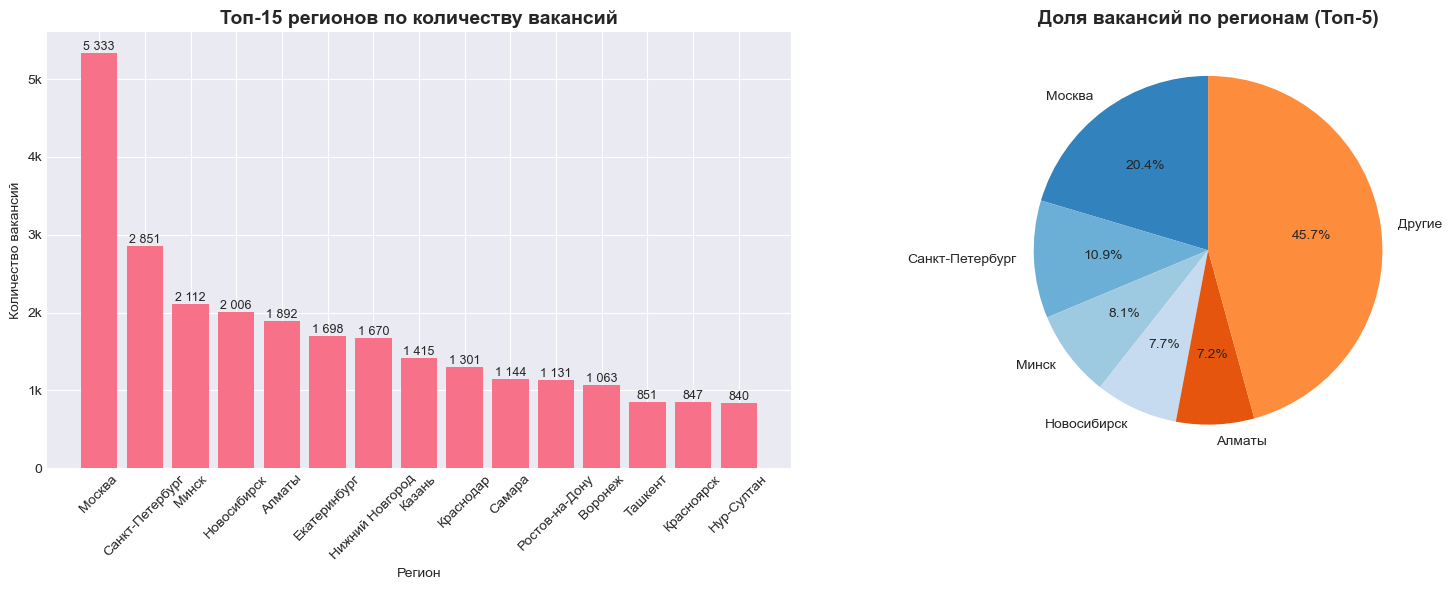

Анализ концентрации:
Всего вакансий в топ-15 регионах: 26,154
Вакансий в топ-5 регионах: 14,194
Концентрация рынка: 54.3% вакансий в 5 регионах
Среднее количество вакансий на регион: 1744
Медианное количество вакансий: 1415

2. АНАЛИЗ ЗАРПЛАТ В DATA SCIENCE ПО ОПЫТУ РАБОТЫ


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2353175892.py:126: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_salary_stats = pd.read_sql_query(query_salary_analysis, connection)


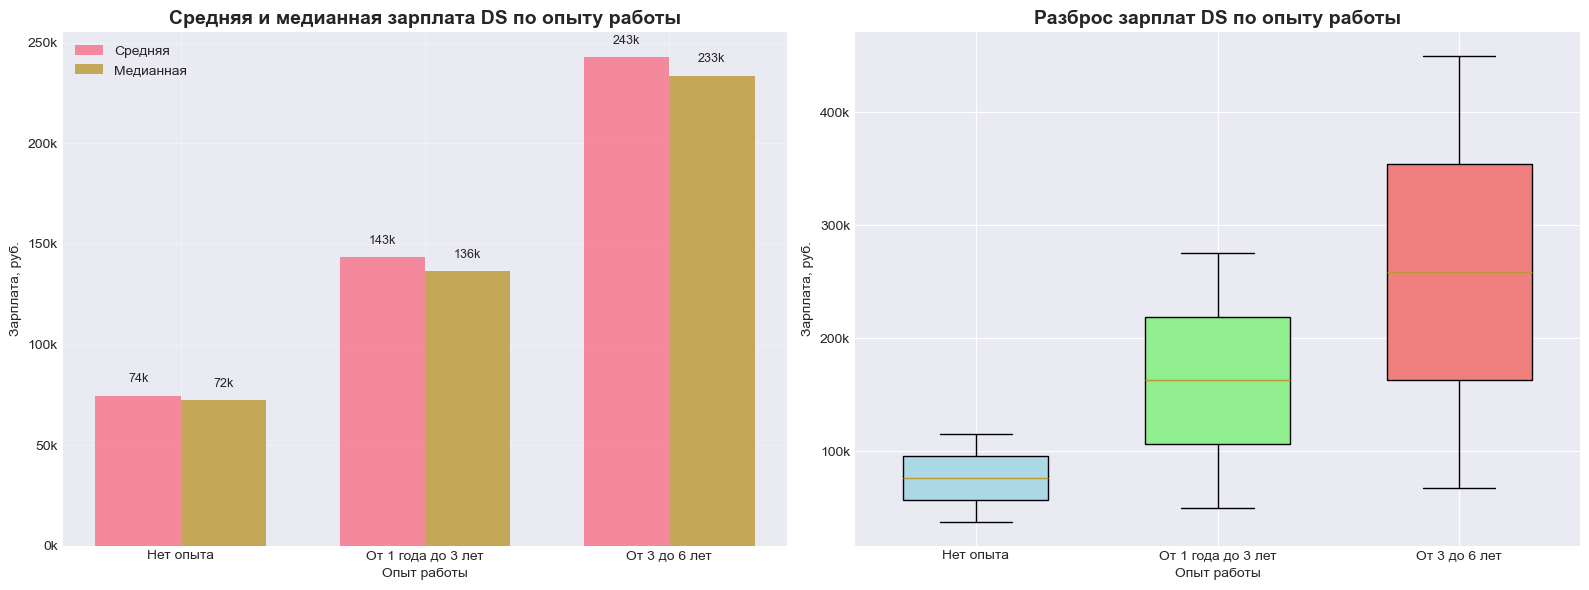


Статистика зарплат DS:

Нет опыта:
  Образец: 7 вакансий
  Средняя: 74,643 руб.
  Медианная: 72,500 руб.
  Диапазон: 37,000 - 115,000 руб.
  Стандартное отклонение: 26,625 руб.

От 1 года до 3 лет:
  Образец: 26 вакансий
  Средняя: 143,417 руб.
  Медианная: 136,750 руб.
  Диапазон: 50,000 - 275,000 руб.
  Стандартное отклонение: 63,201 руб.

От 3 до 6 лет:
  Образец: 27 вакансий
  Средняя: 243,115 руб.
  Медианная: 233,794 руб.
  Диапазон: 67,126 - 450,000 руб.
  Стандартное отклонение: 78,436 руб.

3. АНАЛИЗ КЛЮЧЕВЫХ НАВЫКОВ В DS ВАКАНСИЯХ


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2353175892.py:215: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_skills = pd.read_sql_query(query_skills_analysis, connection)


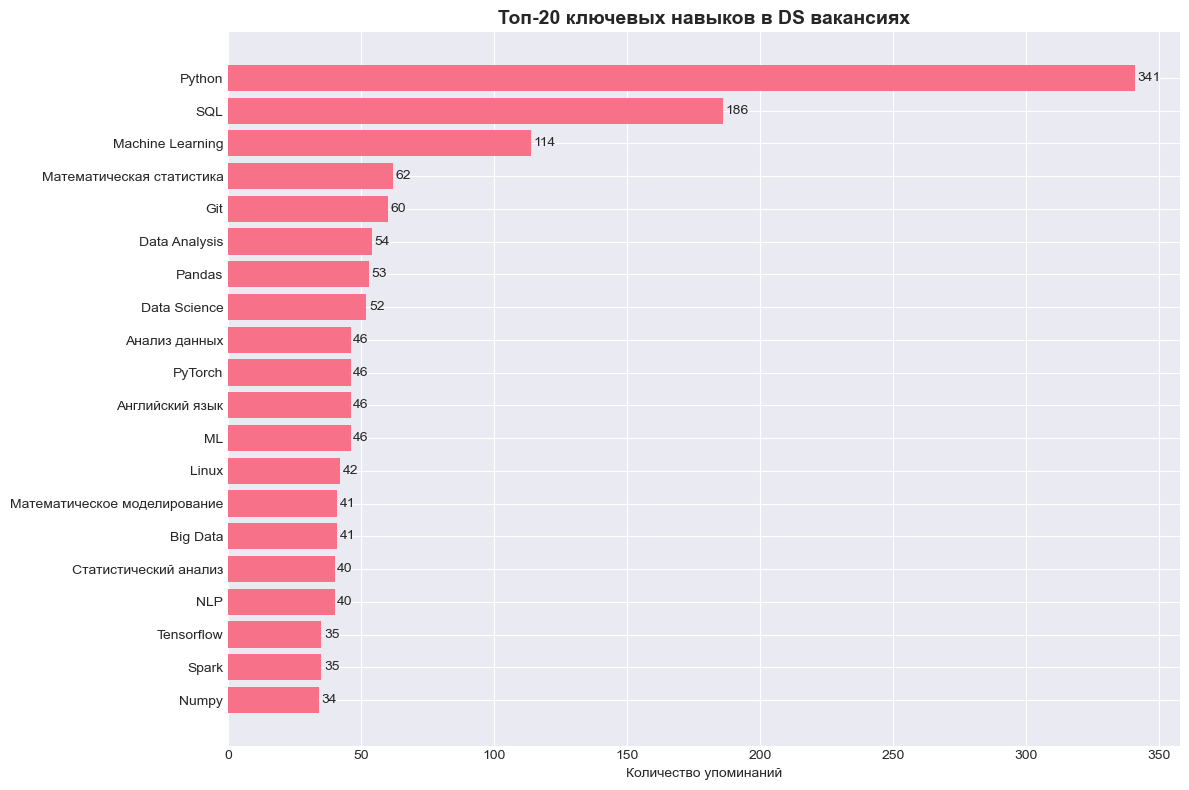

C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2353175892.py:257: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_skills_dist = pd.read_sql_query(query_skills_count, connection)


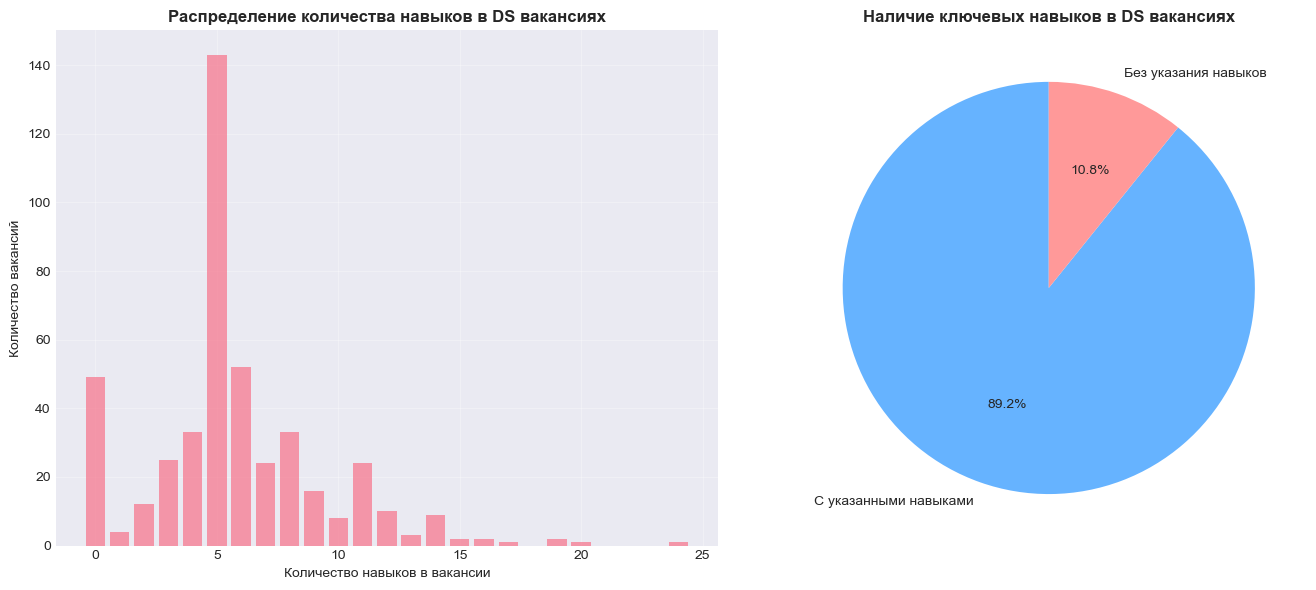


4. АНАЛИЗ РАБОТОДАТЕЛЕЙ В СФЕРЕ ДАННЫХ


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2353175892.py:316: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_employers = pd.read_sql_query(query_employers_analysis, connection)


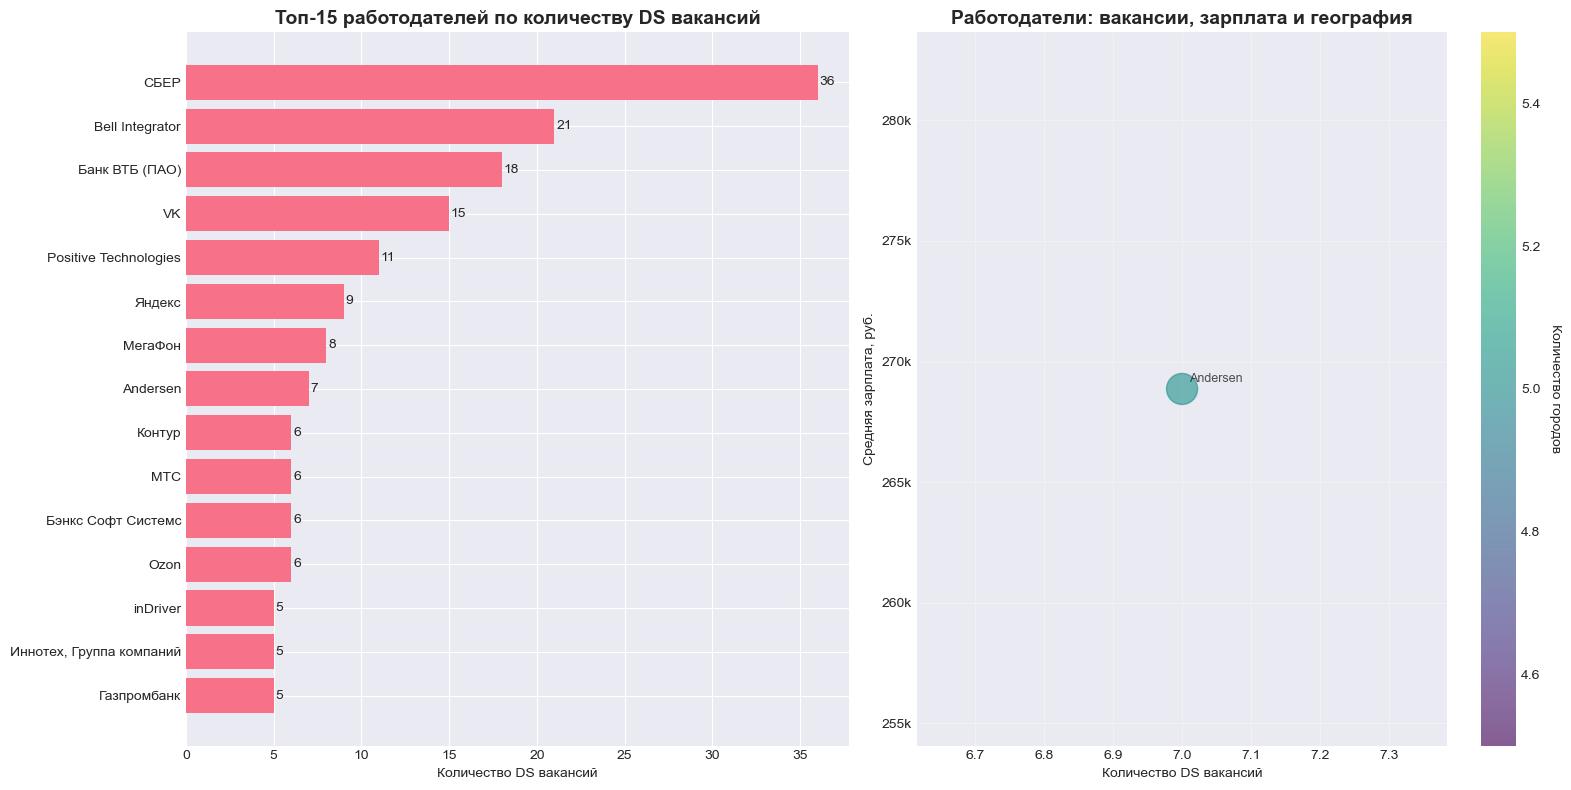


5. ПРОГНОЗЫ И ДОПОЛНИТЕЛЬНЫЕ ИССЛЕДОВАНИЯ

ВОЗМОЖНЫЕ ДОПОЛНИТЕЛЬНЫЕ ИССЛЕДОВАНИЯ:

1. ВРЕМЕННЫЕ ТРЕНДЫ:
   - Динамика количества DS вакансий по месяцам
   - Сезонность найма (когда больше всего вакансий)
   - Тренды зарплат с течением времени

2. ГЕОГРАФИЧЕСКИЙ АНАЛИЗ:
   - Зарплатные различия между регионами
   - Концентрация DS вакансий в столицах vs регионах
   - Удаленная работа vs офис

3. НАВЫКОВЫЙ АНАЛИЗ:
   - Сочетания навыков (какие навыки идут вместе)
   - Эволюция требований к навыкам
   - Специализации внутри DS (CV, NLP, Analytics и т.д.)

4. КАРЬЕРНЫЕ ТРАЕКТОРИИ:
   - Требования к опыту для разных позиций
   - Зарплатная прогрессия с опытом
   - Переходы между смежными специальностями

5. РЫНОЧНЫЕ ТРЕНДЫ:
   - Популярность разных типов занятости (удаленка, гибрид, офис)
   - Спрос на разные уровни (Junior, Middle, Senior)
   - Влияние экономических факторов на рынок DS

Поле с датой не найдено для временного анализа

АНАЛИЗ ЗАВЕРШЕН


C:\Users\ipd08\AppData\Local\Temp\ipykernel_6328\2353175892.py:404: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_date_check = pd.read_sql_query(query_check_date, connection)


In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Функция для форматирования больших чисел
def format_thousands(x, pos):
    return f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'

# 1. Анализ распределения вакансий по регионам
print("="*60)
print("1. АНАЛИЗ РАСПРЕДЕЛЕНИЯ ВАКАНСИЙ ПО РЕГИОНАМ")
print("="*60)

query_regions = """
SELECT 
    a.name as region,
    COUNT(v.id) as vacancy_count
FROM public.areas a
LEFT JOIN public.vacancies v ON a.id = v.area_id
GROUP BY a.name
HAVING COUNT(v.id) > 0
ORDER BY vacancy_count DESC
LIMIT 15
"""

df_regions = pd.read_sql_query(query_regions, connection)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Столбчатая диаграмма топ-15 регионов
bars = ax1.bar(df_regions['region'], df_regions['vacancy_count'])
ax1.set_title('Топ-15 регионов по количеству вакансий', fontsize=14, fontweight='bold')
ax1.set_xlabel('Регион')
ax1.set_ylabel('Количество вакансий')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(FuncFormatter(format_thousands))

# Добавляем значения на столбцы
for bar, count in zip(bars, df_regions['vacancy_count']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{count:,}'.replace(',', ' '),
             ha='center', va='bottom', fontsize=9)

# Круговая диаграмма (только топ-5)
top5 = df_regions.head(5)
other_count = df_regions['vacancy_count'].iloc[5:].sum()
labels = list(top5['region']) + ['Другие']
sizes = list(top5['vacancy_count']) + [other_count]
colors = plt.cm.tab20c(np.arange(len(labels)))

ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Доля вакансий по регионам (Топ-5)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Анализ концентрации
total_vacancies = df_regions['vacancy_count'].sum()
top5_vacancies = top5['vacancy_count'].sum()
concentration_ratio = top5_vacancies / total_vacancies * 100

print(f"Анализ концентрации:")
print(f"Всего вакансий в топ-15 регионах: {total_vacancies:,}")
print(f"Вакансий в топ-5 регионах: {top5_vacancies:,}")
print(f"Концентрация рынка: {concentration_ratio:.1f}% вакансий в 5 регионах")
print(f"Среднее количество вакансий на регион: {df_regions['vacancy_count'].mean():.0f}")
print(f"Медианное количество вакансий: {df_regions['vacancy_count'].median():.0f}")

# 2. Анализ зарплат в Data Science
print("\n" + "="*60)
print("2. АНАЛИЗ ЗАРПЛАТ В DATA SCIENCE ПО ОПЫТУ РАБОТЫ")
print("="*60)

query_salary_analysis = """
WITH ds_salaries AS (
    SELECT 
        experience,
        CASE 
            WHEN salary_from IS NOT NULL AND salary_to IS NOT NULL THEN
                (salary_from + salary_to) / 2.0
            WHEN salary_from IS NOT NULL THEN salary_from
            WHEN salary_to IS NOT NULL THEN salary_to
        END as salary_value
    FROM public.vacancies
    WHERE (
        LOWER(name) LIKE '%data scientist%'
        OR LOWER(name) LIKE '%data science%'
        OR LOWER(name) LIKE '%исследователь данных%'
        OR LOWER(name) LIKE '%machine learning%'
        OR LOWER(name) LIKE '%машинн%обучен%'
        OR name ~* '(^|[^a-zA-Z0-9])ml([^a-zA-Z0-9]|$)'
    )
    AND experience IN ('Нет опыта', 'От 1 года до 3 лет', 'От 3 до 6 лет', 'Более 6 лет')
    AND (salary_from IS NOT NULL OR salary_to IS NOT NULL)
),
filtered_salaries AS (
    SELECT * FROM ds_salaries WHERE salary_value IS NOT NULL
)
SELECT 
    experience,
    ROUND(AVG(salary_value)) as avg_salary,
    ROUND(MIN(salary_value)) as min_salary,
    ROUND(MAX(salary_value)) as max_salary,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY salary_value)) as median_salary,
    COUNT(*) as sample_size,
    ROUND(STDDEV(salary_value)) as salary_stddev
FROM filtered_salaries
GROUP BY experience
ORDER BY 
    CASE experience
        WHEN 'Нет опыта' THEN 1
        WHEN 'От 1 года до 3 лет' THEN 2
        WHEN 'От 3 до 6 лет' THEN 3
        WHEN 'Более 6 лет' THEN 4
        ELSE 5
    END
"""

df_salary_stats = pd.read_sql_query(query_salary_analysis, connection)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Диаграмма средних зарплат
x_pos = np.arange(len(df_salary_stats))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, df_salary_stats['avg_salary'], width, label='Средняя', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, df_salary_stats['median_salary'], width, label='Медианная', alpha=0.8)

ax1.set_xlabel('Опыт работы')
ax1.set_ylabel('Зарплата, руб.')
ax1.set_title('Средняя и медианная зарплата DS по опыту работы', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_salary_stats['experience'])
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Добавляем значения
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 5000,
                 f'{int(height/1000)}k',
                 ha='center', va='bottom', fontsize=9)

# Диаграмма размаха зарплат
salary_data = []
positions = []
for idx, row in df_salary_stats.iterrows():
    salary_data.append([row['min_salary'], row['max_salary']])
    positions.append(idx + 1)

bp = ax2.boxplot(salary_data, positions=positions, widths=0.6, patch_artist=True)
ax2.set_xlabel('Опыт работы')
ax2.set_ylabel('Зарплата, руб.')
ax2.set_title('Разброс зарплат DS по опыту работы', fontsize=14, fontweight='bold')
ax2.set_xticks(positions)
ax2.set_xticklabels(df_salary_stats['experience'])
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

# Раскрашиваем boxplot
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.tight_layout()
plt.show()

print("\nСтатистика зарплат DS:")
for idx, row in df_salary_stats.iterrows():
    print(f"\n{row['experience']}:")
    print(f"  Образец: {row['sample_size']} вакансий")
    print(f"  Средняя: {row['avg_salary']:,.0f} руб.")
    print(f"  Медианная: {row['median_salary']:,.0f} руб.")
    print(f"  Диапазон: {row['min_salary']:,.0f} - {row['max_salary']:,.0f} руб.")
    print(f"  Стандартное отклонение: {row['salary_stddev']:,.0f} руб.")

# 3. Анализ навыков в DS вакансиях
print("\n" + "="*60)
print("3. АНАЛИЗ КЛЮЧЕВЫХ НАВЫКОВ В DS ВАКАНСИЯХ")
print("="*60)

query_skills_analysis = """
WITH ds_skills AS (
    SELECT 
        UNNEST(STRING_TO_ARRAY(REPLACE(key_skills, E'\\t', ','), ',')) as skill,
        COUNT(*) as count
    FROM public.vacancies
    WHERE (
        LOWER(name) LIKE '%data scientist%'
        OR LOWER(name) LIKE '%data science%'
        OR LOWER(name) LIKE '%исследователь данных%'
        OR LOWER(name) LIKE '%machine learning%'
        OR LOWER(name) LIKE '%машинн%обучен%'
        OR name ~* '(^|[^a-zA-Z0-9])ml([^a-zA-Z0-9]|$)'
    )
    AND key_skills IS NOT NULL
    AND TRIM(key_skills) != ''
    GROUP BY UNNEST(STRING_TO_ARRAY(REPLACE(key_skills, E'\\t', ','), ','))
    HAVING COUNT(*) >= 5
    ORDER BY COUNT(*) DESC
    LIMIT 20
)
SELECT * FROM ds_skills
"""

df_skills = pd.read_sql_query(query_skills_analysis, connection)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_skills['skill'], df_skills['count'])
ax.set_xlabel('Количество упоминаний')
ax.set_title('Топ-20 ключевых навыков в DS вакансиях', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Добавляем значения
for bar, count in zip(bars, df_skills['count']):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
            f'{count}',
            ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Анализ распределения количества навыков
query_skills_count = """
SELECT 
    CASE 
        WHEN key_skills IS NULL OR TRIM(key_skills) = '' THEN 0
        ELSE ARRAY_LENGTH(STRING_TO_ARRAY(REPLACE(TRIM(key_skills), E'\\t', ','), ','), 1)
    END as skills_count,
    COUNT(*) as vacancy_count
FROM public.vacancies
WHERE (
    LOWER(name) LIKE '%data scientist%'
    OR LOWER(name) LIKE '%data science%'
    OR LOWER(name) LIKE '%исследователь данных%'
    OR LOWER(name) LIKE '%machine learning%'
    OR LOWER(name) LIKE '%машинн%обучен%'
    OR name ~* '(^|[^a-zA-Z0-9])ml([^a-zA-Z0-9]|$)'
)
GROUP BY CASE 
    WHEN key_skills IS NULL OR TRIM(key_skills) = '' THEN 0
    ELSE ARRAY_LENGTH(STRING_TO_ARRAY(REPLACE(TRIM(key_skills), E'\\t', ','), ','), 1)
END
ORDER BY skills_count
"""

df_skills_dist = pd.read_sql_query(query_skills_count, connection)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Распределение количества навыков
ax1.bar(df_skills_dist['skills_count'], df_skills_dist['vacancy_count'], alpha=0.7)
ax1.set_xlabel('Количество навыков в вакансии')
ax1.set_ylabel('Количество вакансий')
ax1.set_title('Распределение количества навыков в DS вакансиях', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Круговая диаграмма (с навыками и без)
with_skills = df_skills_dist[df_skills_dist['skills_count'] > 0]['vacancy_count'].sum()
without_skills = df_skills_dist[df_skills_dist['skills_count'] == 0]['vacancy_count'].sum()

labels = ['С указанными навыками', 'Без указания навыков']
sizes = [with_skills, without_skills]
colors = ['#66b3ff', '#ff9999']

ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Наличие ключевых навыков в DS вакансиях', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Анализ работодателей в сфере данных
print("\n" + "="*60)
print("4. АНАЛИЗ РАБОТОДАТЕЛЕЙ В СФЕРЕ ДАННЫХ")
print("="*60)

query_employers_analysis = """
SELECT 
    e.name as employer,
    COUNT(v.id) as ds_vacancies,
    COUNT(DISTINCT v.area_id) as cities_count,
    ROUND(AVG(
        CASE 
            WHEN v.salary_from IS NOT NULL AND v.salary_to IS NOT NULL THEN
                (v.salary_from + v.salary_to) / 2.0
            WHEN v.salary_from IS NOT NULL THEN v.salary_from
            WHEN v.salary_to IS NOT NULL THEN v.salary_to
        END
    )) as avg_salary
FROM public.vacancies v
JOIN public.employers e ON v.employer_id = e.id
WHERE (
    LOWER(v.name) LIKE '%data scientist%'
    OR LOWER(v.name) LIKE '%data science%'
    OR LOWER(v.name) LIKE '%исследователь данных%'
    OR LOWER(v.name) LIKE '%machine learning%'
    OR LOWER(v.name) LIKE '%машинн%обучен%'
    OR v.name ~* '(^|[^a-zA-Z0-9])ml([^a-zA-Z0-9]|$)'
)
GROUP BY e.name
HAVING COUNT(v.id) >= 3
ORDER BY ds_vacancies DESC
LIMIT 15
"""

df_employers = pd.read_sql_query(query_employers_analysis, connection)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Топ работодателей по количеству DS вакансий
bars = ax1.barh(df_employers['employer'], df_employers['ds_vacancies'])
ax1.set_xlabel('Количество DS вакансий')
ax1.set_title('Топ-15 работодателей по количеству DS вакансий', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Добавляем значения
for bar, count in zip(bars, df_employers['ds_vacancies']):
    width = bar.get_width()
    ax1.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{count}',
             ha='left', va='center', fontsize=10)

# Пузырьковая диаграмма: вакансии vs зарплата vs города
scatter = ax2.scatter(df_employers['ds_vacancies'], 
                      df_employers['avg_salary'], 
                      s=df_employers['cities_count']*100,
                      alpha=0.6,
                      c=df_employers['cities_count'],
                      cmap='viridis')

ax2.set_xlabel('Количество DS вакансий')
ax2.set_ylabel('Средняя зарплата, руб.')
ax2.set_title('Работодатели: вакансии, зарплата и география', fontsize=14, fontweight='bold')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax2.grid(True, alpha=0.3)

# Добавляем подписи для крупнейших работодателей
for idx, row in df_employers.head(8).iterrows():
    ax2.annotate(row['employer'], 
                (row['ds_vacancies'], row['avg_salary']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.8)

# Цветовая шкала
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Количество городов', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# 5. Анализ временных трендов
print("\n" + "="*60)
print("5. ПРОГНОЗЫ И ДОПОЛНИТЕЛЬНЫЕ ИССЛЕДОВАНИЯ")
print("="*60)

print("""
ВОЗМОЖНЫЕ ДОПОЛНИТЕЛЬНЫЕ ИССЛЕДОВАНИЯ:

1. ВРЕМЕННЫЕ ТРЕНДЫ:
   - Динамика количества DS вакансий по месяцам
   - Сезонность найма (когда больше всего вакансий)
   - Тренды зарплат с течением времени

2. ГЕОГРАФИЧЕСКИЙ АНАЛИЗ:
   - Зарплатные различия между регионами
   - Концентрация DS вакансий в столицах vs регионах
   - Удаленная работа vs офис

3. НАВЫКОВЫЙ АНАЛИЗ:
   - Сочетания навыков (какие навыки идут вместе)
   - Эволюция требований к навыкам
   - Специализации внутри DS (CV, NLP, Analytics и т.д.)

4. КАРЬЕРНЫЕ ТРАЕКТОРИИ:
   - Требования к опыту для разных позиций
   - Зарплатная прогрессия с опытом
   - Переходы между смежными специальностями

5. РЫНОЧНЫЕ ТРЕНДЫ:
   - Популярность разных типов занятости (удаленка, гибрид, офис)
   - Спрос на разные уровни (Junior, Middle, Senior)
   - Влияние экономических факторов на рынок DS
""")

# Проверка наличия поля с датой для временного анализа
try:
    query_check_date = """
    SELECT column_name 
    FROM information_schema.columns 
    WHERE table_name = 'vacancies' 
    AND column_name IN ('created_at', 'published_at', 'date')
    LIMIT 1
    """
    df_date_check = pd.read_sql_query(query_check_date, connection)
    
    if not df_date_check.empty:
        date_column = df_date_check['column_name'][0]
        query_trends = f"""
        SELECT 
            DATE_TRUNC('month', {date_column}) as month,
            COUNT(*) as vacancy_count
        FROM public.vacancies
        WHERE (
            LOWER(name) LIKE '%data scientist%'
            OR LOWER(name) LIKE '%data science%'
            OR LOWER(name) LIKE '%исследователь данных%'
        )
        AND {date_column} IS NOT NULL
        GROUP BY DATE_TRUNC('month', {date_column})
        ORDER BY month
        """
        
        df_trends = pd.read_sql_query(query_trends, connection)
        
        if not df_trends.empty and len(df_trends) > 1:
            fig, ax = plt.subplots(figsize=(12, 6))
            ax.plot(df_trends['month'], df_trends['vacancy_count'], marker='o', linewidth=2)
            ax.set_xlabel('Месяц')
            ax.set_ylabel('Количество вакансий')
            ax.set_title('Динамика количества DS вакансий по месяцам', fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
            
            # Простой линейный тренд
            x = np.arange(len(df_trends))
            z = np.polyfit(x, df_trends['vacancy_count'], 1)
            p = np.poly1d(z)
            trend_slope = z[0]
            
            print(f"Тренд: {'рост' if trend_slope > 0 else 'снижение'} количества DS вакансий")
            print(f"Среднемесячное изменение: {trend_slope:.1f} вакансий")
        else:
            print("Недостаточно данных для временного анализа")
    else:
        print("Поле с датой не найдено для временного анализа")
        
except Exception as e:
    print(f"Временной анализ невозможен: {e}")

print("\n" + "="*60)
print("АНАЛИЗ ЗАВЕРШЕН")
print("="*60)

### Финал

In [166]:
# не забываем закрыть соединение после окончания работы
connection.close()